# <center>Class 15: Regression Trees </center>

#### Prerequisites

In order to be able to display tree objects you need to get `Graphviz` installed on your computer. 
- Installation instructions for Windows can be found [here](https://forum.graphviz.org/t/new-simplified-installation-procedure-on-windows/224). Make soure you choose the `Add Graphviz to the system PATH for current user` option.
- More on `Graphviz` [here](https://graphviz.org/about/)

Once you installed `Graphviz` you need to restart your computer.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import seaborn as sns
import random
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from stargazer import stargazer
from statsmodels.tools.eval_measures import mse,rmse
from patsy import dmatrices

from sklearn.metrics import r2_score,mean_squared_error
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.tree import DecisionTreeRegressor
from collections import Counter
from IPython.display import Image, display

In [2]:
def seq(start, stop, by, round_n=3):
    return [round(x, round_n) for x in list(np.arange(start, stop, by))]

## Data

In [3]:
path = os.path.join(os.pardir, 'data', 'used-cars_2cities_prep.csv') # this will produce a path with the right syntax for your operating system
path

'../data/used-cars_2cities_prep.csv'

In [4]:
# DATA IMPORT - FROM FILE
df = pd.read_csv(path)

In [5]:
df.head()

,pricestr,area,subarea,name,condition,cylinders,drive,fuel,odometer,paintcolor,...,dealer,price,lnprice,year,age,lnodometer,LE,XLE,SE,Hybrid
0,$4990,chicago,chicago city,2007 Toyota Camry Hybrid,good,4 cylinders,fwd,gas,11.6236,grey,...,1,4990,8.515191,2007,11,2.453038,0,0,0,1
1,$10625,chicago,chicago city,2009 Toyota Camry Hybrid,NaN,4 cylinders,fwd,hybrid,4.3702,grey,...,1,10625,9.270965,2009,9,1.474809,0,0,0,1
2,$14850,chicago,chicago city,2015 Toyota_ Camry_,excellent,other,NaN,gas,3.5721,NaN,...,1,14850,9.605755,2015,3,1.273154,0,0,0,0
3,$15630,chicago,chicago city,2016 TOYOTA CAMRY,NaN,NaN,fwd,gas,1.3152,NaN,...,1,15630,9.656947,2016,2,0.273989,0,0,0,0
4,$850,chicago,chicago city,1993 toyota camry,good,6 cylinders,fwd,gas,18.7000,red,...,0,850,6.745236,1993,25,2.928523,0,0,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549 entries, 0 to 548
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   pricestr      549 non-null    object 
 1   area          549 non-null    object 
 2   subarea       540 non-null    object 
 3   name          549 non-null    object 
 4   condition     327 non-null    object 
 5   cylinders     360 non-null    object 
 6   drive         294 non-null    object 
 7   fuel          548 non-null    object 
 8   odometer      549 non-null    float64
 9   paintcolor    316 non-null    object 
 10  size          193 non-null    object 
 11  transmission  549 non-null    object 
 12  type          301 non-null    object 
 13  dealer        549 non-null    int64  
 14  price         549 non-null    int64  
 15  lnprice       549 non-null    float64
 16  year          549 non-null    int64  
 17  age           549 non-null    int64  
 18  lnodometer    549 non-null    

### EDA & feature engineering

**Filtering**

In [7]:
# Manage missing
df["fuel"] = df["fuel"].fillna("Missing")
df["drive"] = df["drive"].fillna("Missing")
df["cylinders"] = df["cylinders"].fillna("Missing")
df["transmission"] = df["transmission"].fillna("Missing")
df["type"] = df["type"].fillna("Missing")

In [8]:
df['condition'].value_counts()

condition
excellent    139
good         114
like new      55
fair          15
new            4
Name: count, dtype: int64

In [9]:
df["condition"] = df["condition"].fillna("good")

In [10]:
df['condition'].value_counts()

condition
good         336
excellent    139
like new      55
fair          15
new            4
Name: count, dtype: int64

In [11]:
# drop hybrid models then drop column
df = (df.query("Hybrid==0")).drop(["Hybrid"], axis=1)

# keep gas-fuelled vehicles
df = df.query("fuel=='gas'")
    # alternative: df = df[df.fuel == 'gas']]

# drop vehicles in fair and new condition, trucks
df = df.query("condition not in ['new','fair']")
    # alternative: df = df[~df.condition.isin(['new','fair'])]

In [12]:
# drop unrealistic values for price and odometer reading
df = df.query("price in @seq(500,25001, 1)").query("odometer<=100")

# drop if price is smaller than 1000 and condition is like new or age is less than 8
df = df.query("~(price < 1000 & (condition == 'like new'|age < 8))")

df = df.query("~(transmission=='manual')")

# drop if truck
df = df.query("type not in ['truck','pickup']")

# drop pricestr
df = df.drop(["pricestr"], axis=1)

In [13]:
# to be on the safe side
df = df[df["price"].notna()]
df.reset_index(drop = True, inplace = True )

In [14]:
df.shape

(477, 21)

**Additional variables**

In [15]:
# condition
df["cond_excellent"] = np.where(df["condition"] == "excellent", 1, 0)
df["cond_good"] = np.where(df["condition"] == "good", 1, 0)
df["cond_likenew"] = np.where(df["condition"] == "like new", 1, 0)
# cylinders
df["cylind6"] = np.where(df["cylinders"] == "6 cylinders", 1, 0)
df.cylinders.value_counts()
df.cylind6.value_counts()
#chicago
df["chicago"] = np.where(df["area"] == "chicago", 1, 0)
# age: quadratic, cubic
df["agesq"] = df["age"] ** 2
df["agecu"] = df["age"] ** 3
# odometer quadratic
df["odometersq"] = df["odometer"] ** 3

In [16]:
df.price.describe().map('{:,.0f}'.format)

count       477
mean      5,844
std       4,335
min         500
25%       2,500
50%       4,400
75%       8,300
max      18,500
Name: price, dtype: object

In [17]:
smp_size=np.floor(0.7*df.shape[0])
smp_size

333.0

In [18]:
# Initialize random seed to make it reproducible
random.seed(20250217)
train_ids = random.sample(range(0, df.shape[0]), int(smp_size))
train_ids[:10]

[476, 385, 109, 188, 407, 254, 56, 346, 22, 87]

In [19]:
df["train"] = 0
df["train"][train_ids] = 1

In [20]:
df["train"].value_counts()

train
1    333
0    144
Name: count, dtype: int64

In [21]:
df_train = df.query('train==1')
df_test = df.query('train==0')

### CART using 'age' as a single predictor variable

#### A single split

Check averages for both train and test, for teaching purpose:

In [22]:
df_train.price.describe().map('{:,.0f}'.format)

count       333
mean      5,740
std       4,261
min         500
25%       2,500
50%       4,300
75%       7,999
max      18,500
Name: price, dtype: object

In [23]:
df_test.price.describe().map('{:,.0f}'.format)

count       144
mean      6,083
std       4,506
min         550
25%       2,500
50%       4,500
75%       8,996
max      17,777
Name: price, dtype: object

In [24]:
cart1 = DecisionTreeRegressor(random_state = 20250217, max_depth = 1)

# Note X should be a matrix instead of series, that's why we need double []
X = df_train[['age']]
y = df_train['price']
cart1.fit(X,y)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",20250217
,"ma

In [25]:
pred_cart1 = cart1.predict(df_test[["age"]])

rmse_cart1 = np.sqrt(mean_squared_error(df_test["price"], pred_cart1))

In [26]:
from sklearn import tree

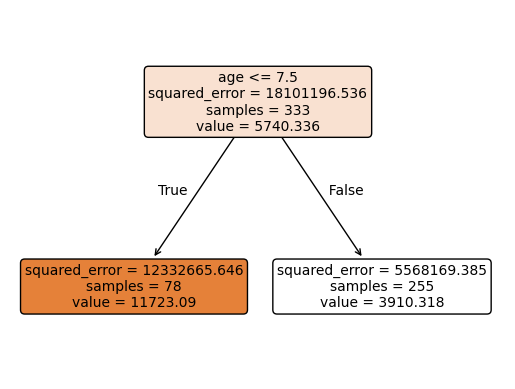

In [35]:
tree.plot_tree(cart1, filled = True, rounded = True, feature_names=["age"], fontsize = 10);
plt.savefig('tree.png')

**Export as png**

In [36]:
pred_cart1t = cart1.predict(df_train[['age']])

In [37]:
cart1.tree_.threshold

array([ 7.5, -2. , -2. ])

In [38]:
cart1_cuts = cart1.tree_.threshold[cart1.tree_.threshold != -2]
cart1_cuts

array([7.5])

In [39]:
df_plot = df_train
df_plot['predicted_price'] = pred_cart1t
df_plot.sort_values(by = 'age', inplace = True)

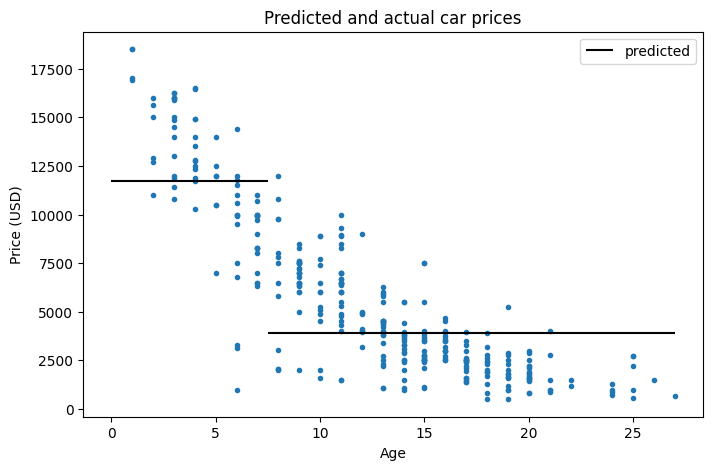

In [40]:
plt.figure(figsize = (8,5))
plt.scatter(x = df_plot.age, y = df_plot.price, marker = '.')
plt.hlines(df_plot.predicted_price.max(), 0, cart1_cuts, color = 'k')
plt.hlines(df_plot.predicted_price.min(), cart1_cuts, df_plot.age.max(), color = 'k', label = 'predicted')
plt.legend()
plt.ylabel('Price (USD)')
plt.xlabel('Age')
plt.title('Predicted and actual car prices')
plt.show();

### Splits at two levels (setting "max_depth" to 2)

In [41]:
cart2 = DecisionTreeRegressor(random_state=20250217, max_depth=2)
# Note X should be a matrix instead of series, that's why we need double []
X = df_train[["age"]]
y = df_train["price"]
cart2.fit(X, y)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",20250217
,"ma

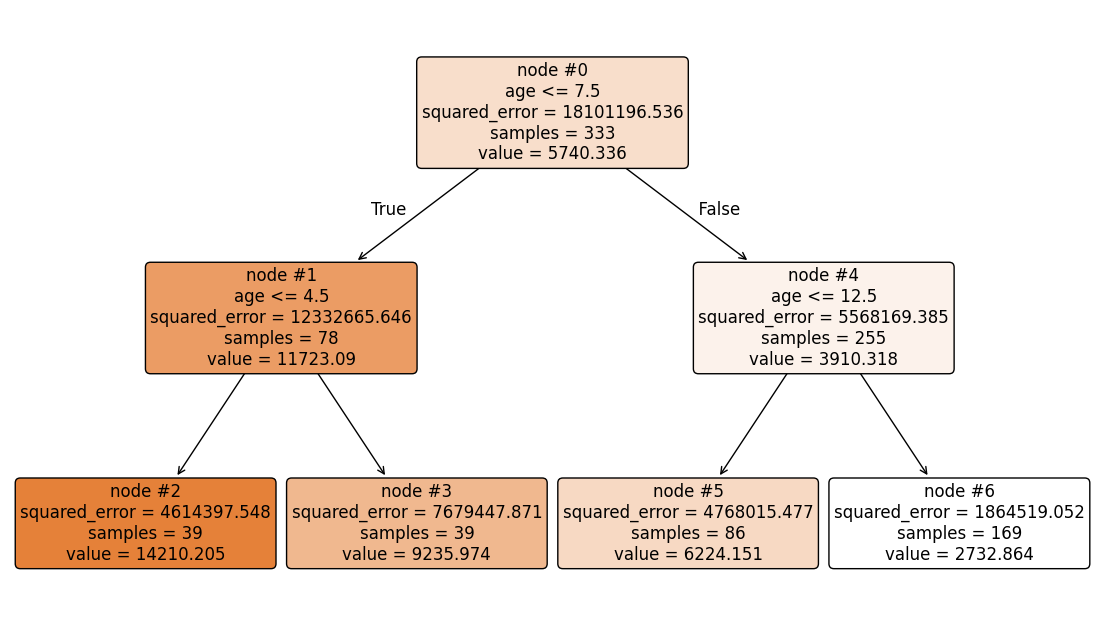

In [42]:
plt.figure(figsize = (14,8))
tree.plot_tree(cart2, filled = True, rounded = True, feature_names=["age"], fontsize = 12, node_ids = True);

In [43]:
# Cut points
cuts = cart2.tree_.threshold[cart2.tree_.threshold != -2]
cuts

array([ 7.5,  4.5, 12.5])

In [44]:
for x in cuts:
    print(int(np.floor(x)), int(np.floor(x) + 1))

7 8
4 5
12 13


In [45]:
# Groups
groups = [0]
for x in cuts:
    groups += [int(np.floor(x)), int(np.floor(x) + 1)]
    
groups = sorted(groups) + ["or more"]
groups

[0, 4, 5, 7, 8, 12, 13, 'or more']

In [46]:
# get the leaf for each observations for the training sample
leaves_index = cart2.apply(X)
leaves_index # => these are all terminal leaves only!

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,

In [47]:
# use Counter to find the number of elements on each leaf
cnt = Counter(sorted(leaves_index))
cnt

Counter({6: 169, 5: 86, 2: 39, 3: 39})

In [48]:
# and now you can index each input to get the number of elements
elems = [cnt[x] for x in leaves_index]
print(elems[:10], '\t', elems[-10:])

[39, 39, 39, 39, 39, 39, 39, 39, 39, 39] 	 [169, 169, 169, 169, 169, 169, 169, 169, 169, 169]


In [49]:
counts=list(cnt.values())
counts

[39, 39, 86, 169]

In [50]:
av_price = (
    pd.DataFrame({"index": leaves_index, "fit": cart2.predict(X)})
    .drop_duplicates()
    .sort_values("index")["fit"]
    .tolist()
)
av_price

[14210.205128205129, 9235.97435897436, 6224.1511627906975, 2732.8639053254437]

In [55]:
for x, y in enumerate(
                [
                    "Age " + str(groups[i]) + "-" + str(groups[i + 1])
                    for i in range(len(groups) - 1)
                ]):
    print(x, "   ", y)

0     Age 0-4
1     Age 4-5
2     Age 5-7
3     Age 7-8
4     Age 8-12
5     Age 12-13
6     Age 13-or more


In [56]:
pd.DataFrame(
    {
        "Category": [
            y
            for x, y in enumerate(
                [
                    "Age " + str(groups[i]) + "-" + str(groups[i + 1])
                    for i in range(len(groups) - 1)
                ]
            )
            if x % 2 == 0
        ],
        "Count": counts,
        "Average_price": av_price,
    }
)

,Category,Count,Average_price
0,Age 0-4,39,14210.205128
1,Age 5-7,39,9235.974359
2,Age 8-12,86,6224.151163
3,Age 13-or more,169,2732.863905


In [57]:
pred_cart2 = cart2.predict(df_test[["age"]])

rmse_cart2 = np.sqrt(mean_squared_error(df_test["price"], pred_cart2))

In [58]:
print(f'CART2 RMSE: {rmse_cart2:,.1f}')

CART2 RMSE: 2,089.9


In [59]:
pred_cart2

array([ 2732.86390533,  2732.86390533,  2732.86390533,  2732.86390533,
        6224.15116279,  2732.86390533,  6224.15116279,  2732.86390533,
        2732.86390533,  2732.86390533,  2732.86390533,  2732.86390533,
        2732.86390533,  2732.86390533,  6224.15116279,  9235.97435897,
        6224.15116279,  2732.86390533,  2732.86390533,  2732.86390533,
        2732.86390533,  6224.15116279,  2732.86390533,  2732.86390533,
        2732.86390533,  6224.15116279,  2732.86390533,  2732.86390533,
        6224.15116279,  2732.86390533,  6224.15116279,  2732.86390533,
        9235.97435897, 14210.20512821,  6224.15116279,  2732.86390533,
        2732.86390533,  2732.86390533,  2732.86390533,  2732.86390533,
       14210.20512821,  2732.86390533, 14210.20512821, 14210.20512821,
        6224.15116279,  9235.97435897, 14210.20512821,  2732.86390533,
        9235.97435897, 14210.20512821,  6224.15116279,  6224.15116279,
        2732.86390533,  2732.86390533,  9235.97435897, 14210.20512821,
      

In [60]:
df_plot = df_train
df_plot['predicted_price'] = cart2.predict(df_train[["age"]])
df_plot.sort_values(by = 'age', inplace = True)

In [61]:
df_plot[['age', 'predicted_price']]

,age,predicted_price
380,1,14210.205128
74,1,14210.205128
92,1,14210.205128
448,1,14210.205128
444,2,14210.205128
...,...,...
72,25,2732.863905
87,25,2732.863905
77,25,2732.863905
451,26,2732.863905


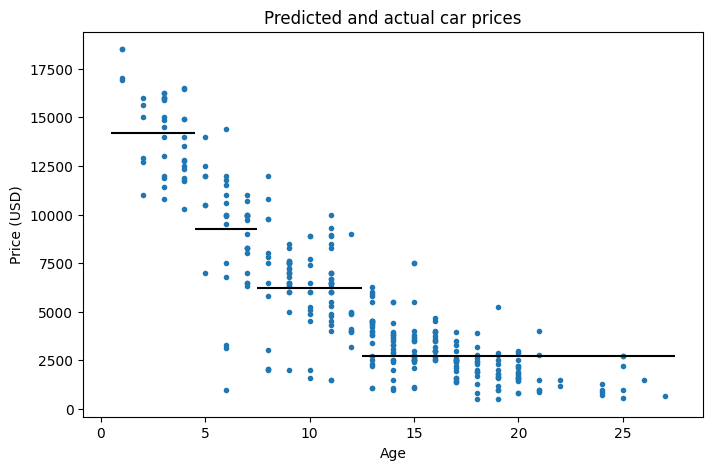

In [62]:
plt.figure(figsize = (8,5))
plt.scatter(x = df_plot.age, y = df_plot.price, marker = '.')
for price in df_plot.predicted_price.unique():
    xmin = df_plot[df_plot.predicted_price == price].age.min() -0.5
    xmax = df_plot[df_plot.predicted_price == price].age.max() + 0.5
    plt.hlines(price, xmin, xmax, color = 'k')
# plt.legend()
plt.ylabel('Price (USD)')
plt.xlabel('Age')
plt.title('Predicted and actual car prices')
plt.show();

#### Splitting using the *complexity parameter*

**Note**: 
- `min_impurity_decrease` in sklearn is considered to be the same as complexity parameter; the actual values are different but the purpose is the same
- `squared error` as *criterion* (measuring the quality of the split) stands for `mean squared error`. There is no metric targeting $R^2$.

In [79]:
cart3 = DecisionTreeRegressor(
    random_state=20250217, criterion="squared_error", min_impurity_decrease=50000
)
# Note X should be a matrix instead of series, that's why we need double []
X = df_train[["age"]]
y = df_train["price"]
cart3.fit(X, y)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",20250217
,

In [80]:
pred_cart3 = cart3.predict(df_test[["age"]])

rmse_cart3 = np.sqrt(mean_squared_error(df_test["price"], pred_cart3))

In [81]:
print(f'CART3 RMSE: {rmse_cart3:,.1f}')

CART3 RMSE: 1,973.4


In [82]:
sorted([x for x in cart3.tree_.threshold if x > -2])

[1.5, 4.5, 5.5, 7.5, 11.5, 12.5, 16.5]

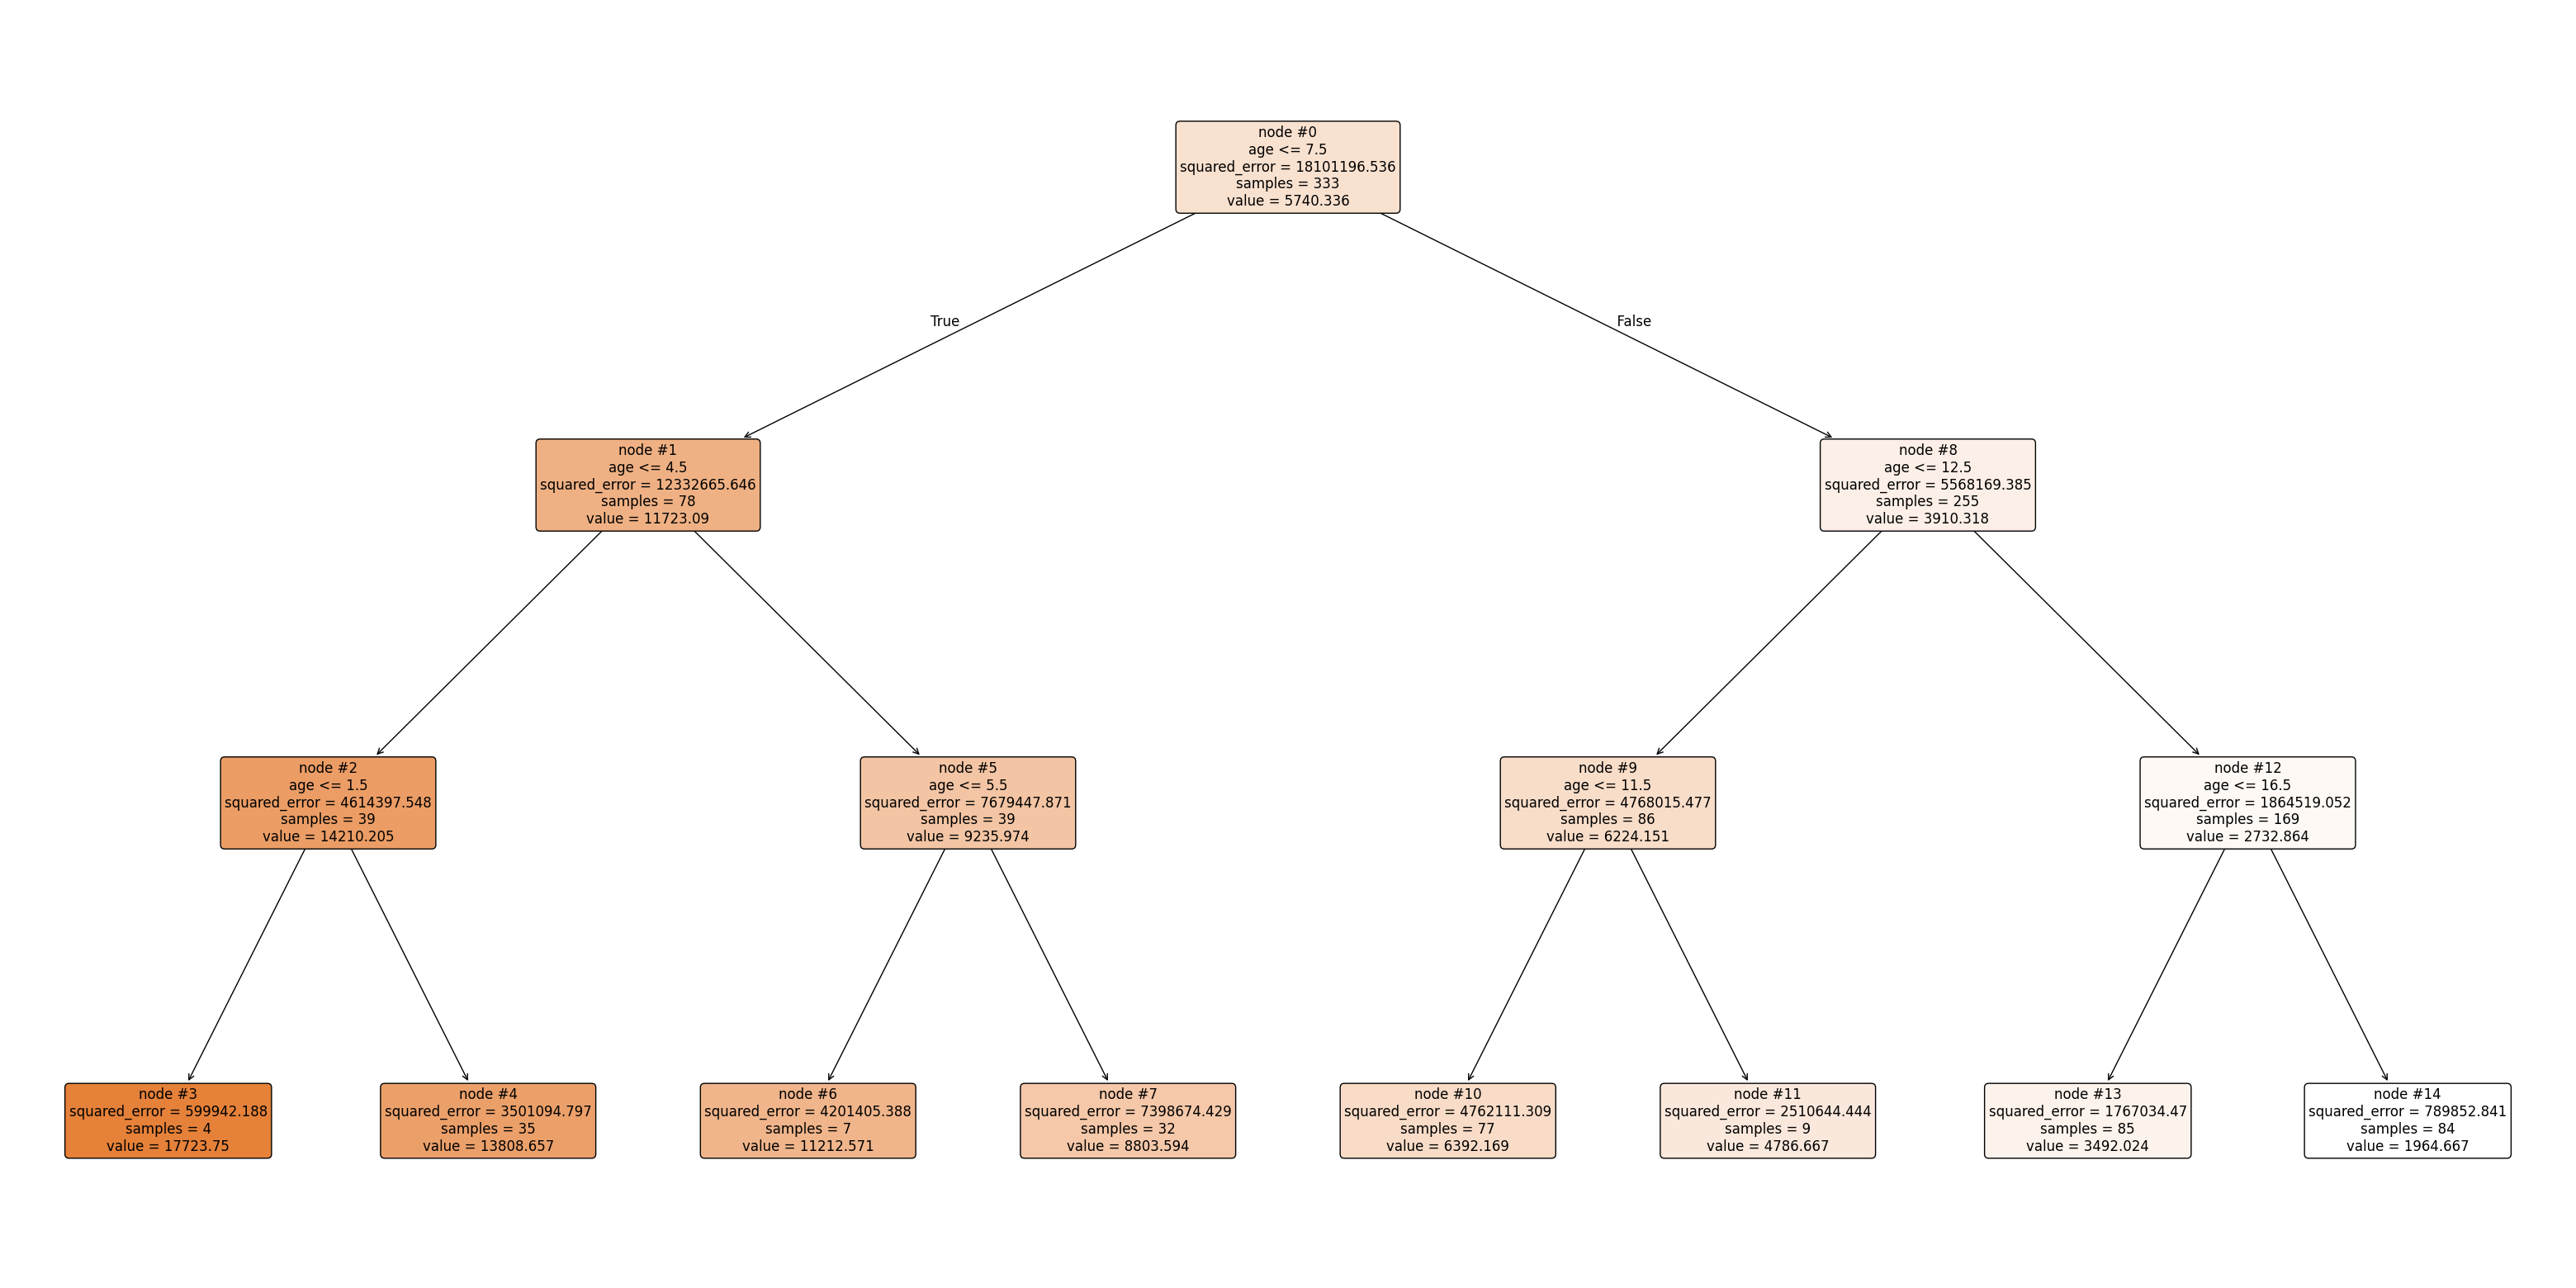

In [83]:
plt.figure(figsize = (40,20))
tree.plot_tree(cart3, filled = True, rounded = True, feature_names=["age"], fontsize = 12, node_ids = True);

In [84]:
pred_cart3t = cart3.predict(df_train[["age"]])

In [85]:
df_plot = df_train
df_plot['predicted_price'] = pred_cart3t
df_plot.sort_values(by = 'age', inplace = True)

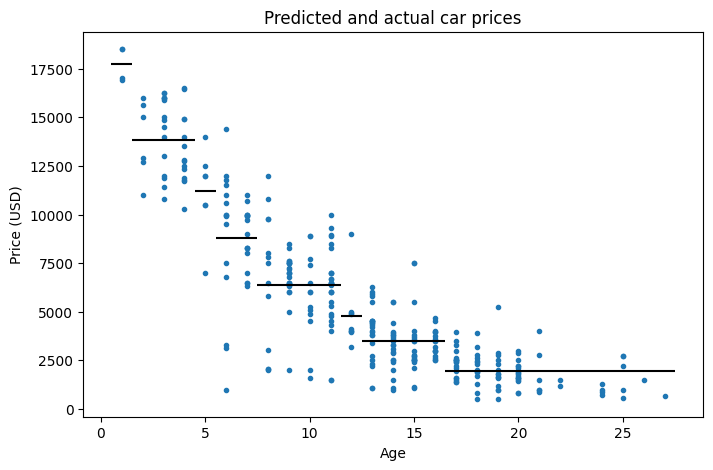

In [86]:
plt.figure(figsize = (8,5))
plt.scatter(x = df_plot.age, y = df_plot.price, marker = '.')
for price in df_plot.predicted_price.unique():
    xmin = df_plot[df_plot.predicted_price == price].age.min() -0.5
    xmax = df_plot[df_plot.predicted_price == price].age.max() + 0.5
    plt.hlines(price, xmin, xmax, color = 'k')
# plt.legend()
plt.ylabel('Price (USD)')
plt.xlabel('Age')
plt.title('Predicted and actual car prices')
plt.show();

#### Age only linear regression
---

In [87]:
linreg1=smf.ols("price~age",data=df_train).fit()
print(linreg1.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.723
Model:                            OLS   Adj. R-squared:                  0.722
Method:                 Least Squares   F-statistic:                     862.8
Date:                Wed, 21 Jan 2026   Prob (F-statistic):           3.25e-94
Time:                        18:57:00   Log-Likelihood:                -3041.4
No. Observations:                 333   AIC:                             6087.
Df Residuals:                     331   BIC:                             6094.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    1.35e+04    291.415     46.320      0.0

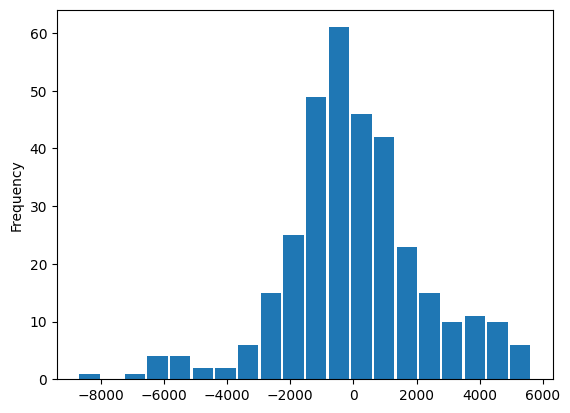

In [88]:
linreg1.resid.plot(kind = 'hist', bins = 20, rwidth = 0.9);

In [89]:
pred_linreg1 = linreg1.predict(df_test)
rmse_ols1 = np.sqrt(mean_squared_error(df_test["price"], pred_linreg1))
rmse_ols1

2399.7858214028233

In [90]:
## Scatterplot with predicted values
pred_linreg1t=linreg1.predict(df_train)

In [91]:
df_plot = df_train
df_plot['predicted_price'] = pred_linreg1t
df_plot.sort_values(by = 'age', inplace = True)

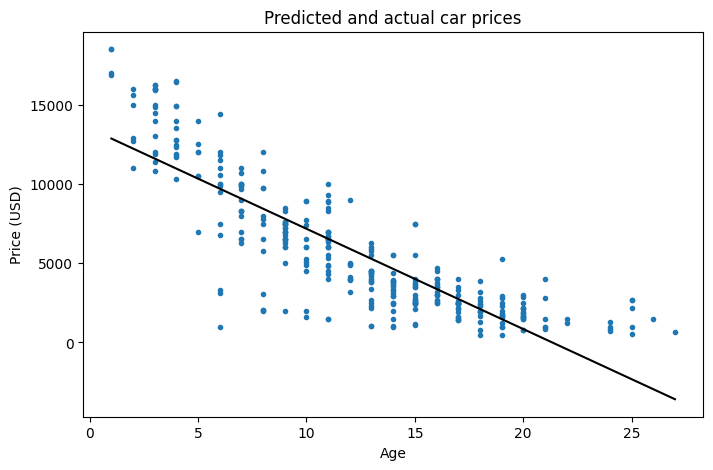

In [92]:
plt.figure(figsize = (8,5))
plt.scatter(x = df_plot.age, y = df_plot.price, marker = '.')
plt.plot(df_plot.age, df_plot.predicted_price, color = 'k')
plt.ylabel('Price (USD)')
plt.xlabel('Age')
plt.title('Predicted and actual car prices')
plt.show();

#### Loess using `statsmodels`

In [93]:
lowess = sm.nonparametric.lowess

In [94]:
lowess1=lowess(df_train.price,df_train.age,)
#lowess1=lowess(df_train.price,df_train.age)

In [95]:
pred_lowess1 = lowess(df_test.price, df_test.age)
pred_lowess1 = [x[1] for x in pred_lowess1]
rmse_lowess1 = np.sqrt(mean_squared_error(df_test["price"], pred_lowess1))

pred_lowess1t = lowess(df_train.price, df_train.age)
pred_lowess1t = [x[1] for x in pred_lowess1t]

In [96]:
df_lowess = df_train.copy()
df_lowess["pred_lowess1t"] = pred_lowess1t
df_lowess.sort_values(by = 'age', inplace = True)

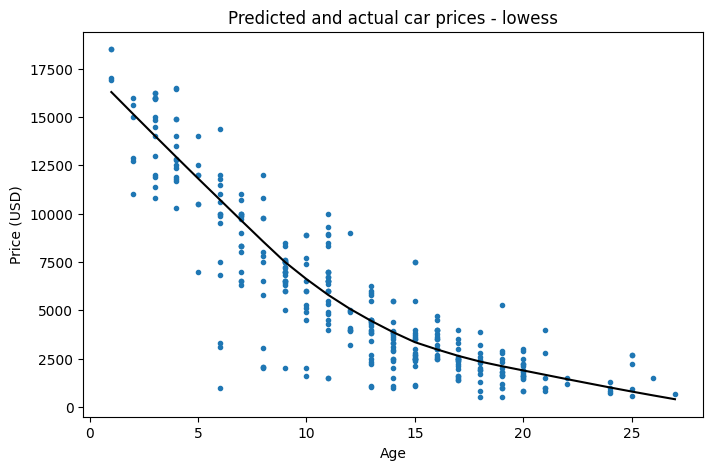

In [97]:
plt.figure(figsize = (8,5))
plt.scatter(x = df_lowess.age, y = df_lowess.price, marker = '.')
plt.plot(df_lowess.age, df_lowess.pred_lowess1t, color = 'k')
plt.ylabel('Price (USD)')
plt.xlabel('Age')
plt.title('Predicted and actual car prices - lowess')
plt.show();

### CART using multiple predictor variables

#### Linear regression baselines

In [98]:
# Linear regression with multiple variables
model2 = "price ~ age + odometer + LE + XLE + SE + cond_excellent + cond_good + cylind6 + dealer + chicago"
linreg2 = smf.ols(model2, df_train).fit()
print(linreg2.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.815
Model:                            OLS   Adj. R-squared:                  0.809
Method:                 Least Squares   F-statistic:                     142.0
Date:                Wed, 21 Jan 2026   Prob (F-statistic):          1.20e-111
Time:                        18:58:03   Log-Likelihood:                -2973.9
No. Observations:                 333   AIC:                             5970.
Df Residuals:                     322   BIC:                             6012.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         1.4e+04    414.084     33.

In [100]:
pred_linreg2 = linreg2.predict(df_test)
rmse_linreg2 = np.sqrt(mean_squared_error(df_test["price"], pred_linreg2))
rmse_linreg2

1907.2025274798214

In [101]:
# add squared for age, odometer
model3 = "price ~ age + agesq+ odometer+odometersq +LE + XLE + SE + cond_excellent + cond_good + cylind6 + dealer+chicago"
linreg3 = smf.ols(model3, df_train).fit()
print(linreg3.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.877
Model:                            OLS   Adj. R-squared:                  0.872
Method:                 Least Squares   F-statistic:                     189.4
Date:                Wed, 21 Jan 2026   Prob (F-statistic):          2.13e-137
Time:                        18:59:02   Log-Likelihood:                -2906.6
No. Observations:                 333   AIC:                             5839.
Df Residuals:                     320   BIC:                             5889.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       1.731e+04    437.205     39.

In [102]:
pred_linreg3 = linreg3.predict(df_test)
rmse_linreg3 = np.sqrt(mean_squared_error(df_test["price"], pred_linreg3))
rmse_linreg3

1568.0510167144682

#### Trees

In [103]:
y, X = dmatrices(model2, df_train)

**Splitting at four levels, for illustrative purposes (by setting "maxdepth" to 3)**

In [104]:
cart4 = DecisionTreeRegressor(
    random_state=20250217, criterion="squared_error",max_depth=3
)
cart4.fit(X, y)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",20250217
,"ma

In [105]:
y_test, X_test = dmatrices(model2, df_test)

pred_cart4 = cart4.predict(X_test)
rmse_cart4 = np.sqrt(mean_squared_error(y_test, pred_cart4))
rmse_cart4

2183.63061366748

In [106]:
feature_names_model2 = [
    "price",
    "age",
    "odometer",
    "LE",
    "XLE",
    "SE",
    "cond_excellent",
    "cond_good",
    "cylind6",
    "dealer",
    "chicago",
]

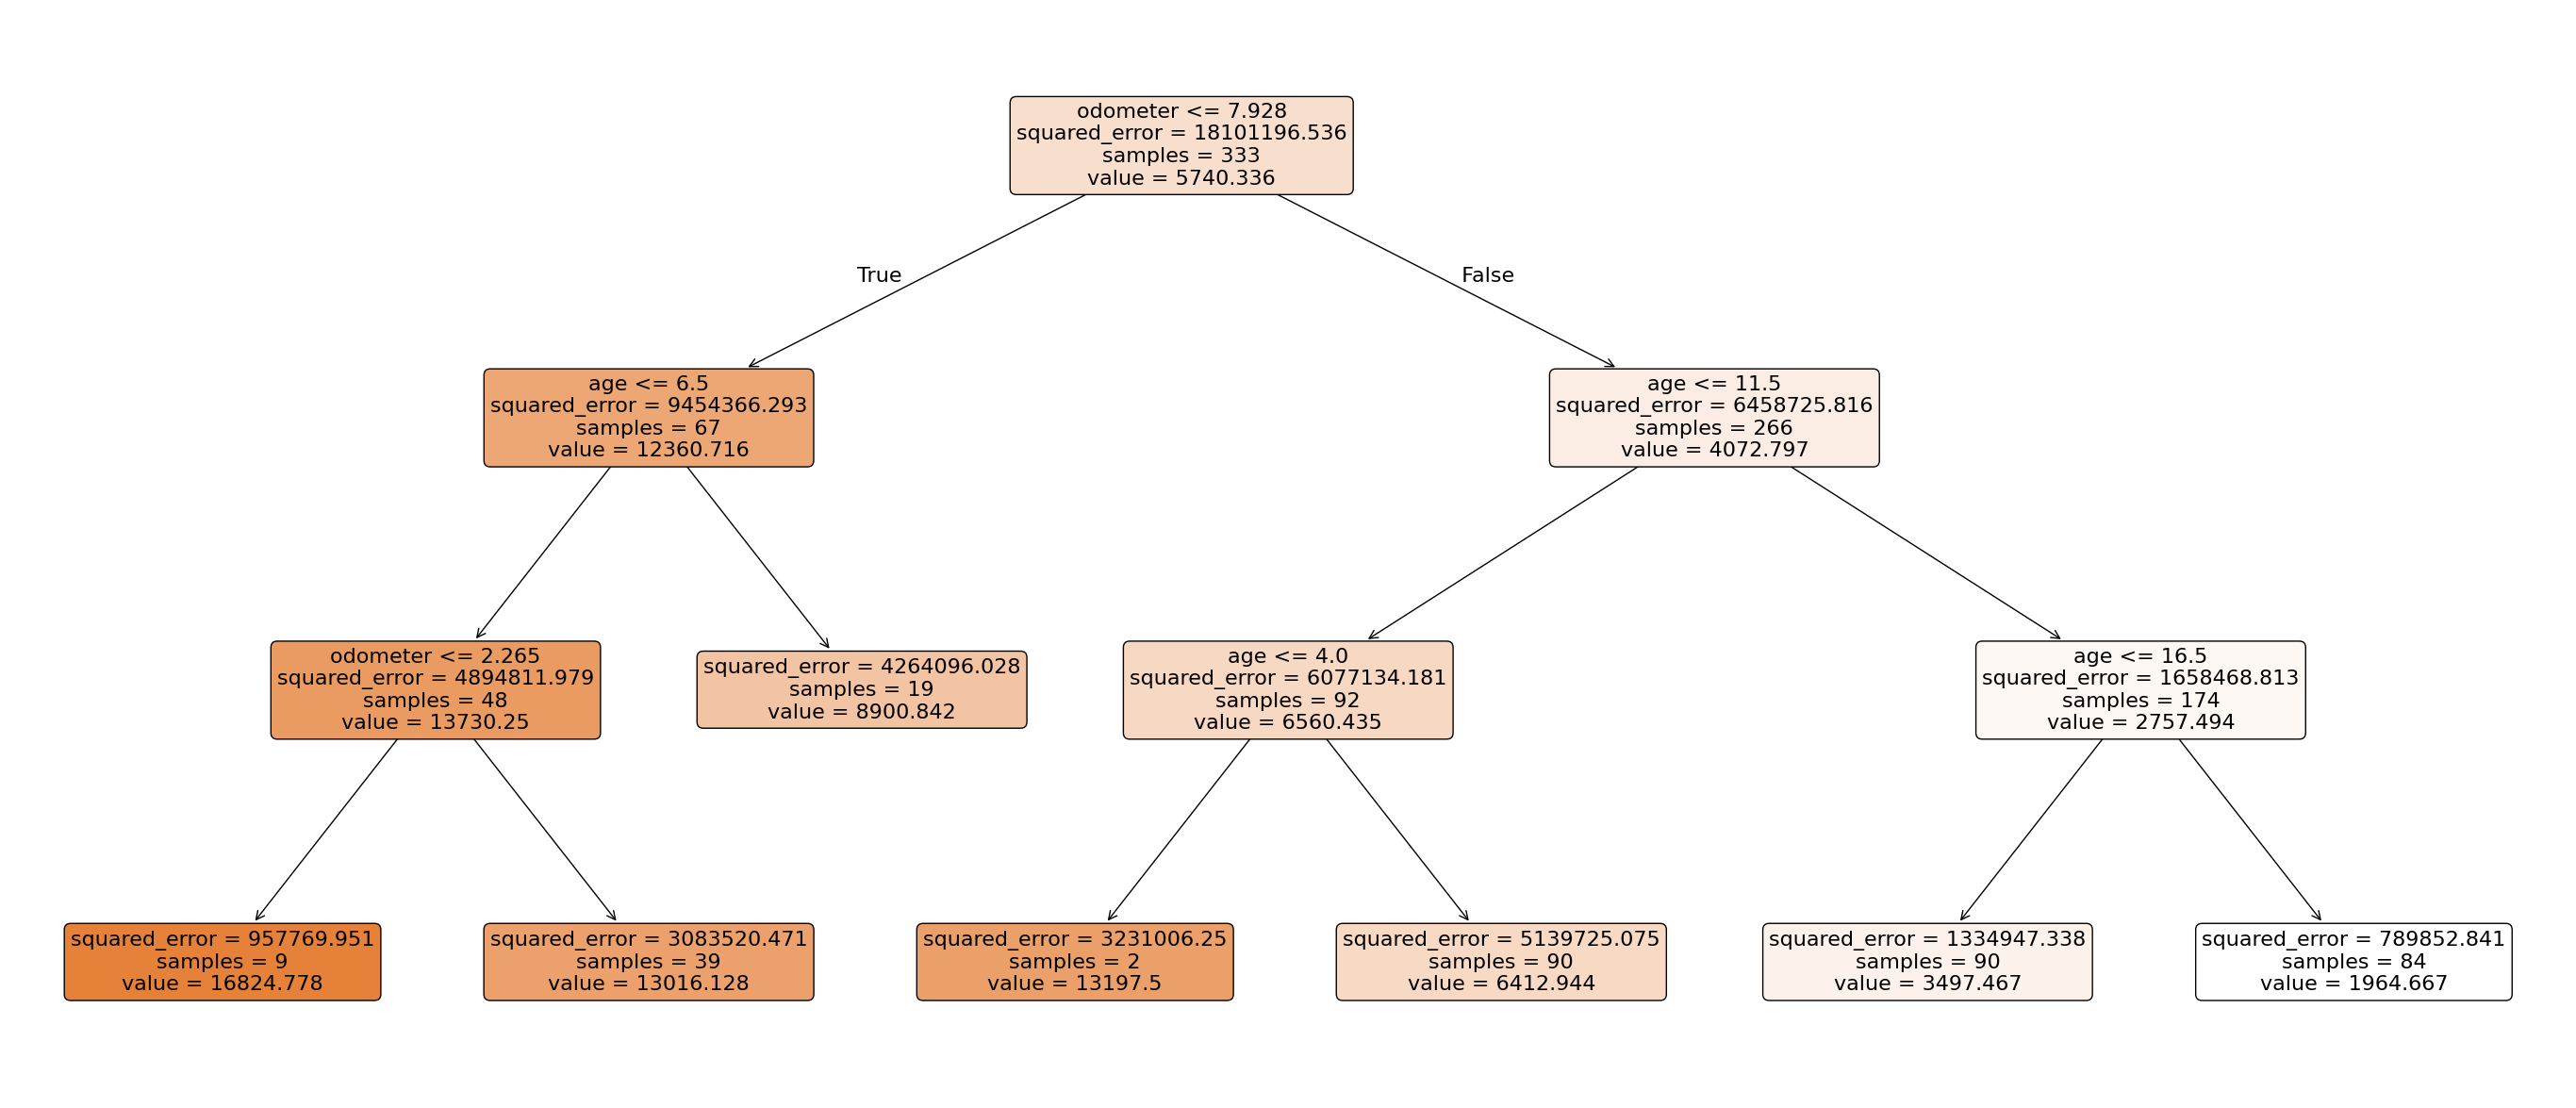

In [109]:
plt.figure(figsize = (35,15))
tree.plot_tree(cart4, filled = True, rounded = True, feature_names= feature_names_model2, fontsize = 16);

**Alternative: using of min_impurity_decrease**

In [110]:
cart4 = DecisionTreeRegressor(
    random_state=20250217,
    criterion="squared_error",
    min_impurity_decrease=145000,
    min_samples_split=20,
)
cart4.fit(X, y)

y_test, X_test = dmatrices(model2, df_test)

pred_cart4 = cart4.predict(X_test)
rmse_cart4 = np.sqrt(mean_squared_error(y_test, pred_cart4))
rmse_cart4

1989.3311231699297

In [111]:
cart5 = DecisionTreeRegressor(
    random_state=20270217,
    criterion="squared_error",
    min_impurity_decrease=20000,
)
cart5.fit(X, y)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",20270217
,

In [112]:
pred_cart5 = cart5.predict(X_test)
rmse_cart5 = np.sqrt(mean_squared_error(y_test, pred_cart5))
rmse_cart5

2170.802674857586

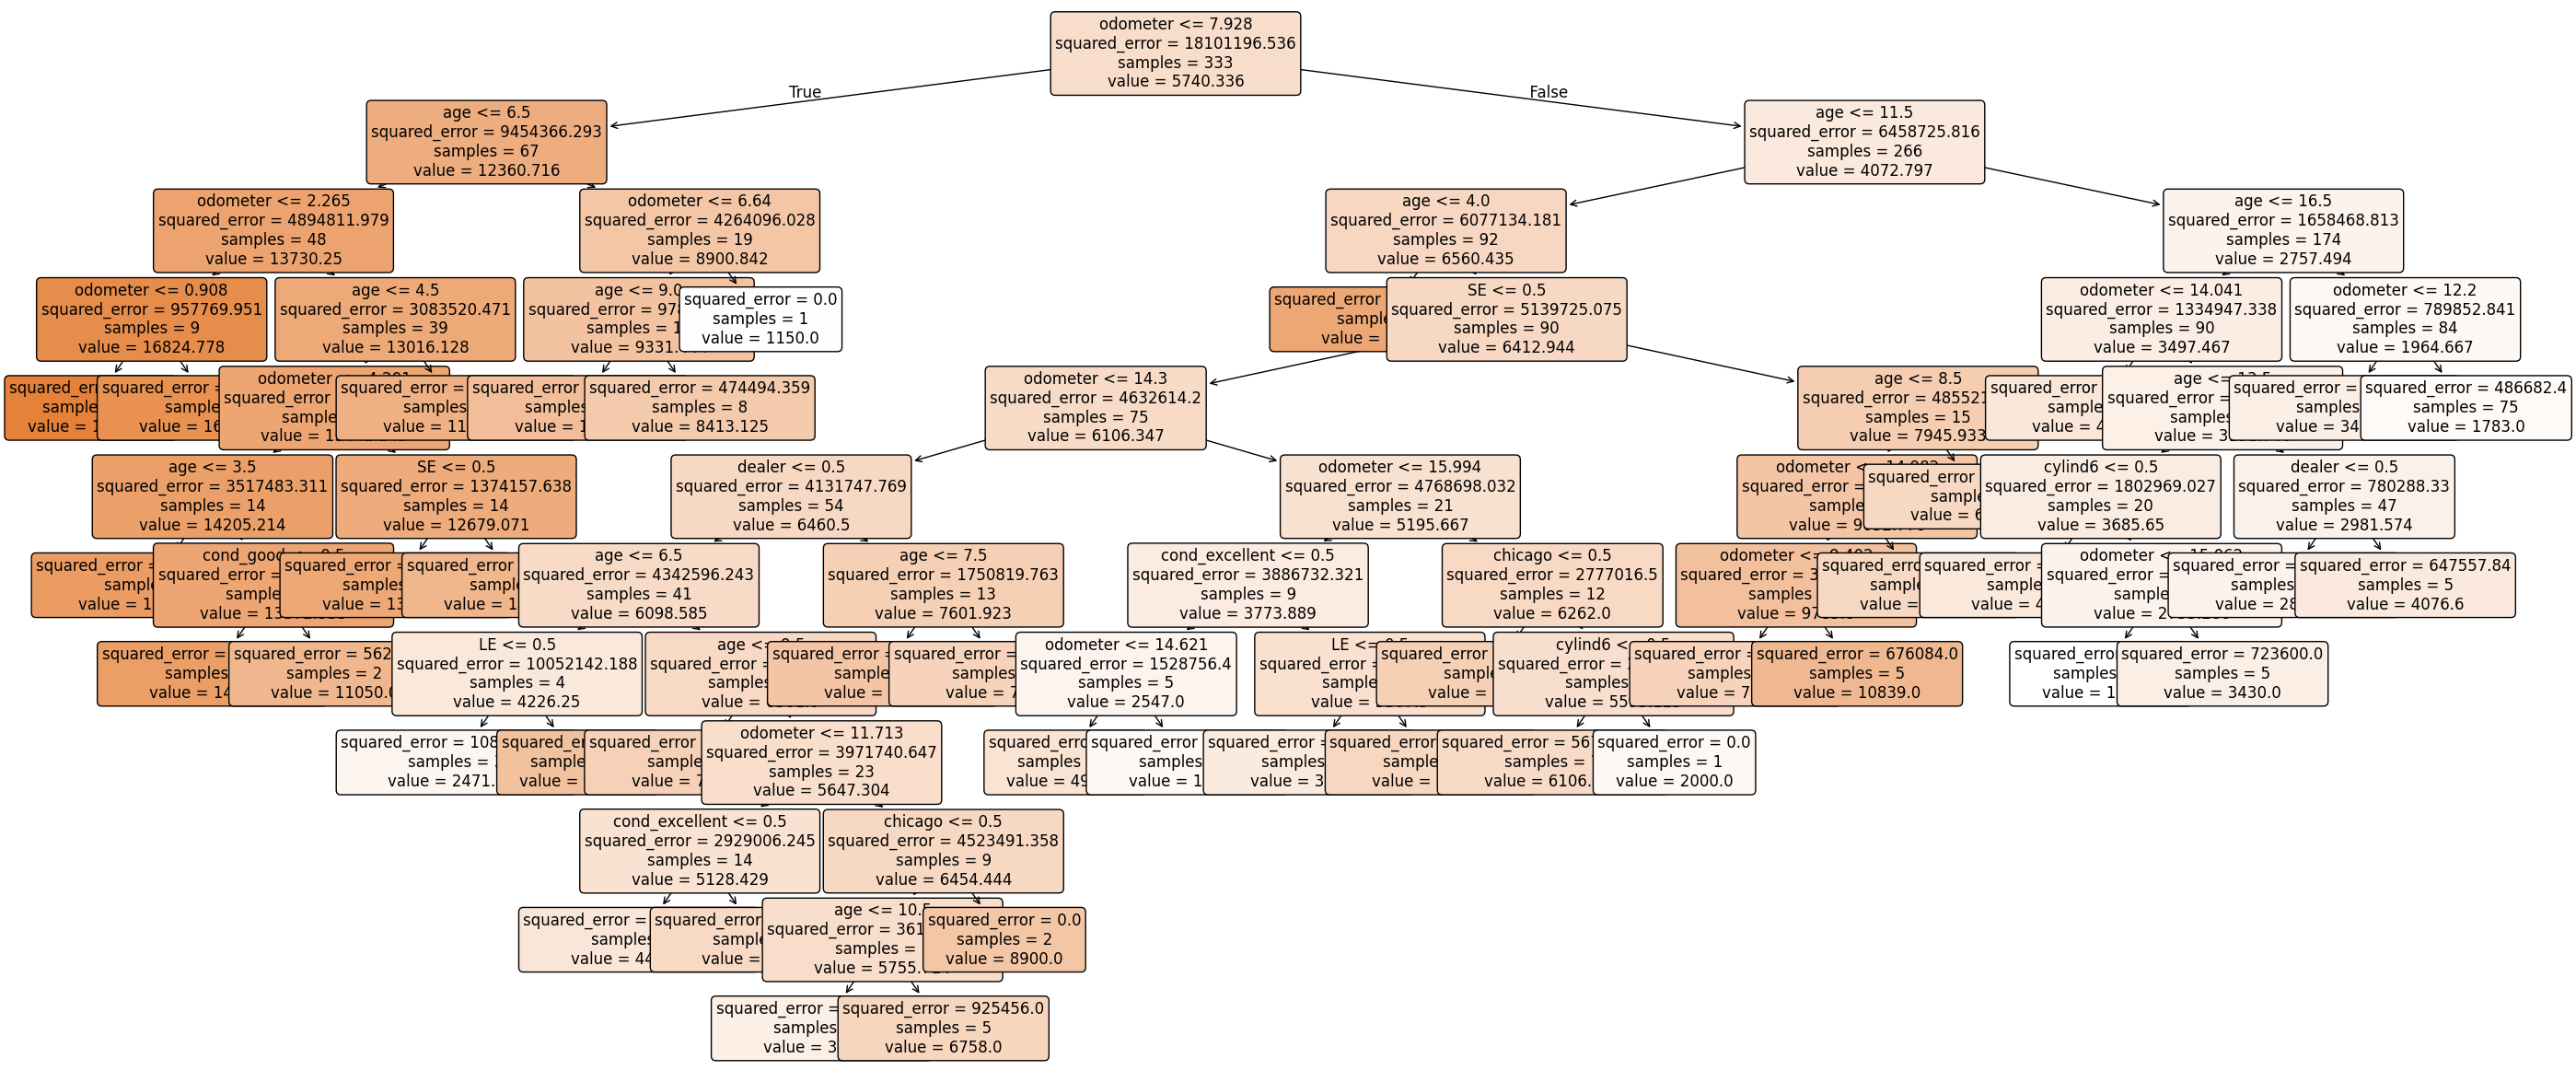

In [113]:
plt.figure(figsize = (35,15))
tree.plot_tree(cart5, filled = True, rounded = True, feature_names= feature_names_model2, fontsize = 12);

**Build very large tree and prune it**

Set the `ccp_alpha` [parameter](https://scikit-learn.org/stable/modules/tree.html#minimal-cost-complexity-pruning).

In [114]:
cart6 = DecisionTreeRegressor(
    random_state=20250217, min_samples_split=4, criterion="squared_error",ccp_alpha=30000
)
cart6.fit(X, y)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",20250217
,

In [115]:
pred_cart6 = cart6.predict(X_test)
rmse_cart6 = np.sqrt(mean_squared_error(y_test, pred_cart6))
rmse_cart6

2230.2302065922795

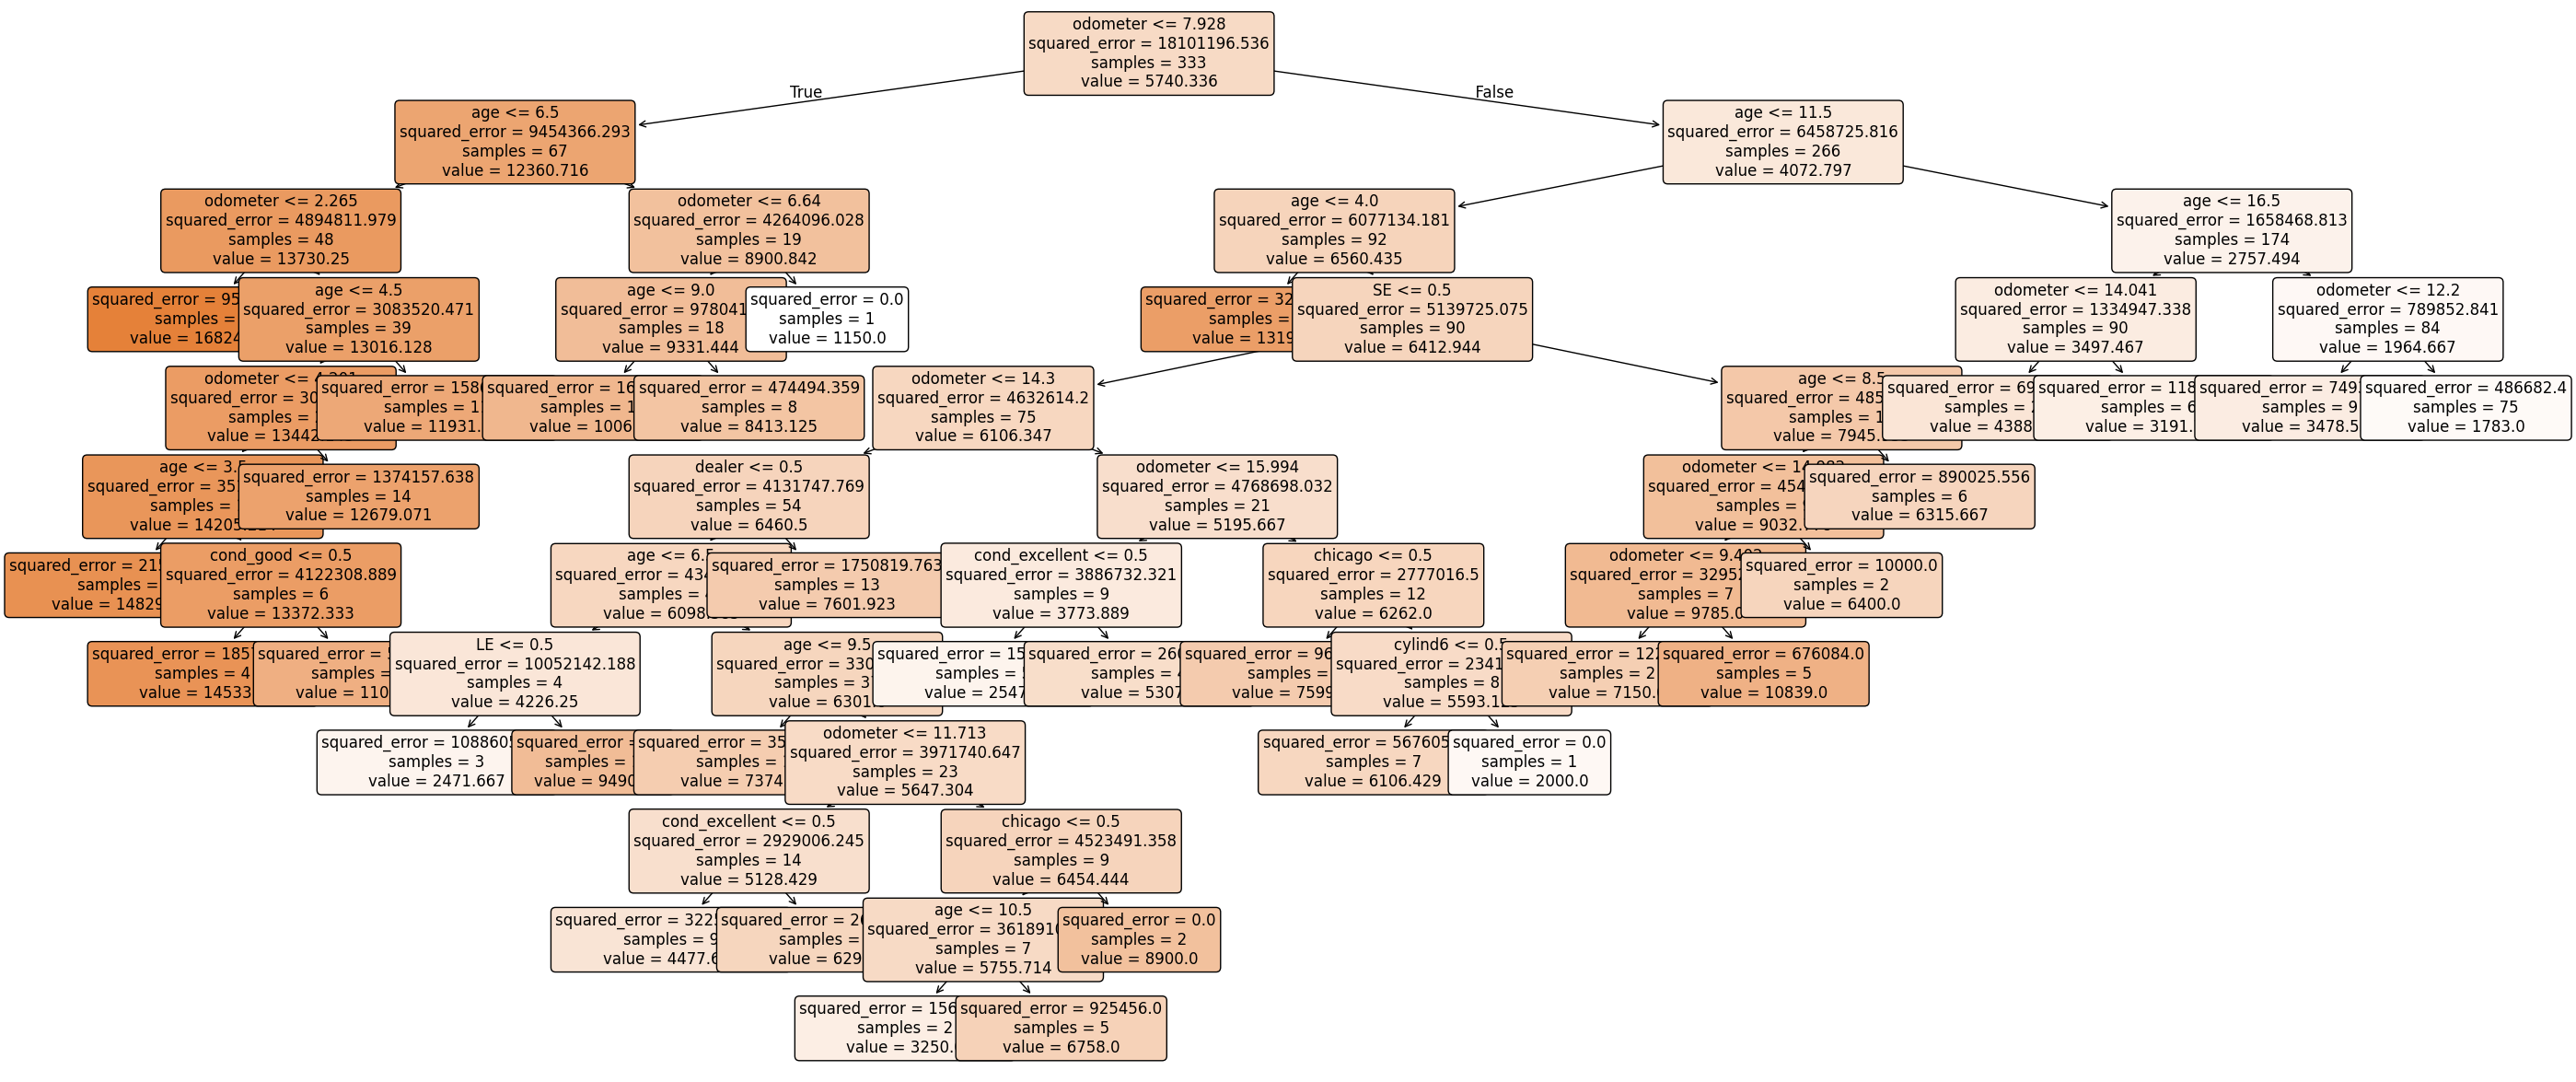

In [116]:
plt.figure(figsize = (35,15))
tree.plot_tree(cart6, filled = True, rounded = True, feature_names= feature_names_model2, fontsize = 12);

#### Plot variable importance for model 6

In [117]:
cart6.feature_importances_

array([0.        , 0.26361297, 0.70372949, 0.00647909, 0.        ,
       0.00741883, 0.00484161, 0.00283763, 0.00258774, 0.00391229,
       0.00458036])

In [118]:
cart6.feature_importances_.sum()

1.0

In [119]:
df_cart6_var_imp = (
    pd.DataFrame(
        {'variable': feature_names_model2, 
         'importance': cart6.feature_importances_}
    ).sort_values(
        by=["importance"], ascending=False
    ).reset_index(drop = True)
)

In [120]:
df_cart6_var_imp

,variable,importance
0,odometer,0.703729
1,age,0.263613
2,SE,0.007419
3,LE,0.006479
4,cond_excellent,0.004842
5,chicago,0.004580
6,dealer,0.003912
7,cond_good,0.002838
8,cylind6,0.002588
9,price,0.000000


Using Pandas `plot` method.

In [121]:
df_ = df_cart6_var_imp.sort_values(by = 'importance', ascending = True)

In [122]:
df_.importance = df_.importance *100

<Figure size 640x480 with 0 Axes>

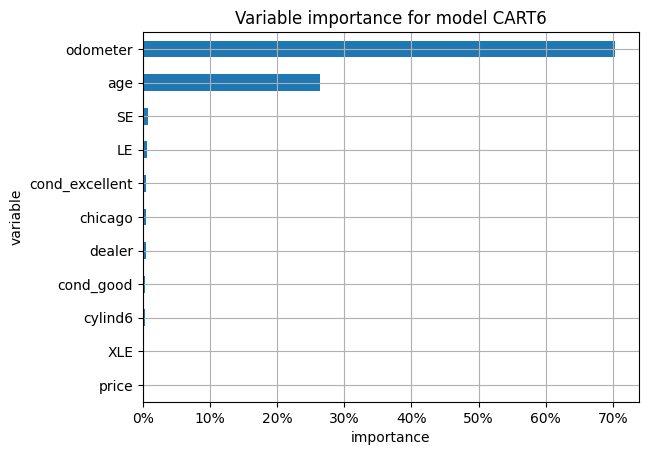

In [123]:
import matplotlib.ticker as mtick

plt.figure()
ax = df_.plot(
    kind = 'barh', x = 'variable', y = 'importance', 
    legend = False, grid = True, 
    xlabel = 'importance', ylabel = 'variable', 
    title = 'Variable importance for model CART6')
ax.set_xticks([x for x in range(0,100, 10)])
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
plt.plot();

In [124]:
pd.DataFrame(
    {
        "Model": ["CART M" + str(i) for i in range(1, 7)]
        + ["OLS M" + str(i) for i in range(1, 4)],
        "Number of variables": [1, 1, 7, 7, 7, 7, 1, 7, 7],
        "Model details": [
            "2 levels",
            "3 levels",
            "min_impurity_decrease=50000",
            "min_impurity_decrease=140000 & min_samples_split=20",
            "min_impurity_decrease=20000",
            "ccp_alpha=30000",
            "linear",
            "linear",
            "w/ polynomial terms",
        ],
        "RMSE": [
            rmse_cart1,
            rmse_cart2,
            rmse_cart3,
            rmse_cart4,
            rmse_cart5,
            rmse_cart6,
            rmse_ols1,
            rmse_linreg2,
            rmse_linreg3,
        ],
    }
).set_index("Model")

,Number of variables,Model details,RMSE
Model,,,
CART M1,1,2 levels,2564.105903
CART M2,1,3 levels,2089.882062
CART M3,7,min_impurity_decrease=50000,1973.419119
CART M4,7,min_impurity_decrease=140000 & min_samples_spl...,1989.331123
CART M5,7,min_impurity_decrease=20000,2170.802675
CART M6,7,ccp_alpha=30000,2230.230207
OLS M1,1,linear,2399.785821
OLS M2,7,linear,1907.202527
OLS M3,7,w/ polynomial terms,1568.051017


### Build a Simple OLS Based on CART Feature Importances

In [128]:
# add squared for age, odometer
model_final = "price ~ age + agesq+ odometer+odometersq"
linreg_final = smf.ols(model_final, df_train).fit()
print(linreg_final.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.865
Model:                            OLS   Adj. R-squared:                  0.864
Method:                 Least Squares   F-statistic:                     526.6
Date:                Wed, 21 Jan 2026   Prob (F-statistic):          2.43e-141
Time:                        19:15:48   Log-Likelihood:                -2921.2
No. Observations:                 333   AIC:                             5852.
Df Residuals:                     328   BIC:                             5871.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.834e+04    351.415     52.179      0.0

In [129]:
pred_linreg_final = linreg_final.predict(df_test)
rmse_linreg_final = np.sqrt(mean_squared_error(df_test["price"], pred_linreg_final))

In [130]:
print(f'{rmse_linreg_final:,.1f}')

1,651.5


In [131]:
linreg_final.params.map('{:,.1f}'.format)

Intercept     18,336.4
age           -1,003.5
agesq             22.6
odometer        -413.0
odometersq         0.3
dtype: object

### Re-cap of pros and cons

Stability:
Linear Regression is more stable.

Interpretability:
CART has clear split points.

Functional form:
It uses constant for a bin.

Computation:
OLS is cheaper.